In [1]:
# Importing all ncessary libraries for statistical arbitrage on ETF 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

import statsmodels
import seaborn
from statsmodels.tsa.stattools import coint


In [2]:
# Ticker selected manually after researching online about ETF representing similar undelying NIFTYBEE AND SETFNIF50


tickers = ["NIFTYBEES.NS" , "SETFNIF50.NS"]

data = yf.download(tickers, start="2015-08-01")["Close"]

data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,NIFTYBEES.NS,SETFNIF50.NS
Date,,
2015-08-03,86.635002,82.397476
2015-08-04,86.302002,81.798943
2015-08-05,86.712997,81.327141
2015-08-06,87.000999,81.522957
2015-08-07,86.711998,83.233513


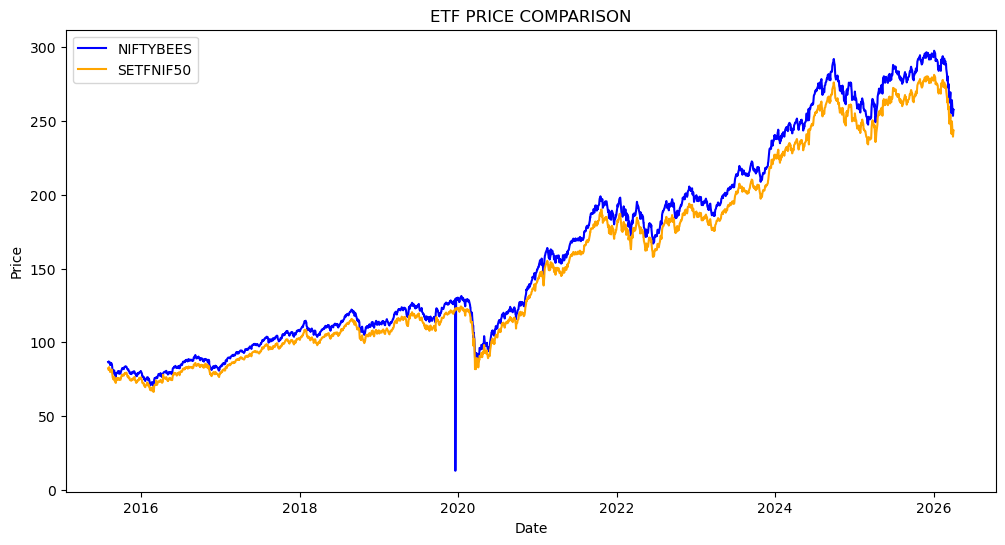

In [3]:
#Visually checking line grap for close price of both ETF to check if price move shows similarity or not.
# And as we see both ETF price shows similarity 

plt.figure(figsize=(12,6))

plt.plot(data["NIFTYBEES.NS"], label="NIFTYBEES", color="blue")
plt.plot(data["SETFNIF50.NS"], label="SETFNIF50", color="orange")

plt.title("ETF PRICE COMPARISON")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

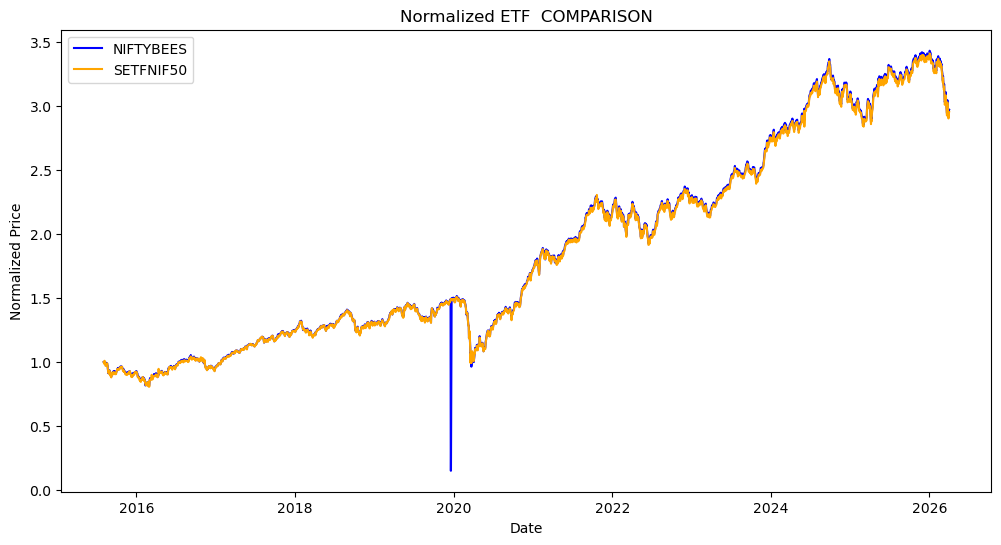

In [4]:

normalized = data/data.iloc[0]

plt.figure(figsize=(12,6))

plt.plot(normalized["NIFTYBEES.NS"], label="NIFTYBEES", color="blue")
plt.plot(normalized["SETFNIF50.NS"], label="SETFNIF50", color="orange")

plt.title("Normalized ETF  COMPARISON")
plt.xlabel("Date")
plt.ylabel("Normalized Price")

plt.legend()
plt.show()

In [5]:
# We can see spike on both chart for Niftybees , we will clean and erase all data with 0 price or na price.

In [6]:
data = data.dropna()
data = data[(data>0).all(axis=1)]

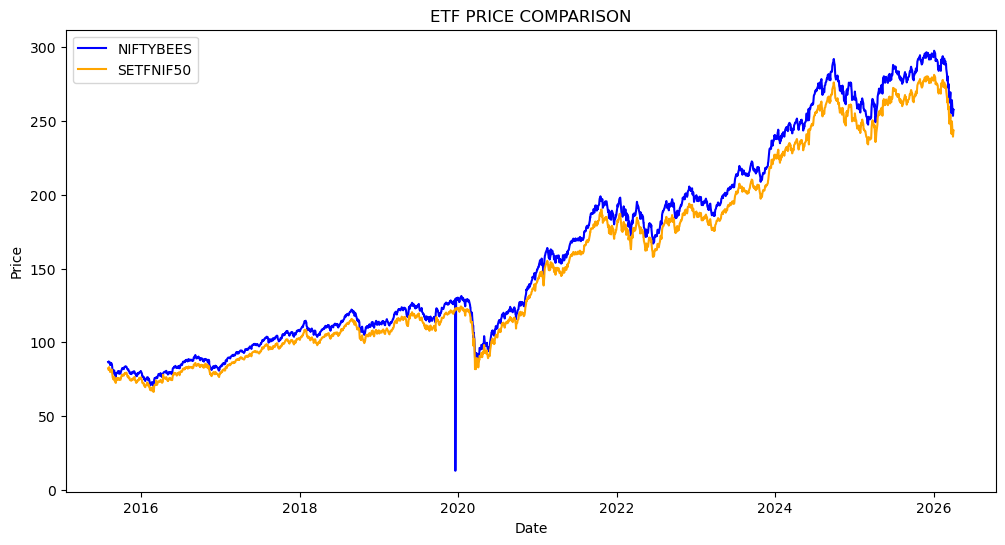

In [7]:
plt.figure(figsize=(12,6))

plt.plot(data["NIFTYBEES.NS"], label="NIFTYBEES", color="blue")
plt.plot(data["SETFNIF50.NS"], label="SETFNIF50", color="orange")

plt.title("ETF PRICE COMPARISON")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

In [8]:
# Spike is still visible even after cleaing with price>0 and removin nan output . Seems like some glithc in data 
# we need to normalise this data with price >50 for niftybee becaause in real market we cannot buy at rs10 realistically 


In [9]:
data = data[(data["NIFTYBEES.NS"] > 50 )]

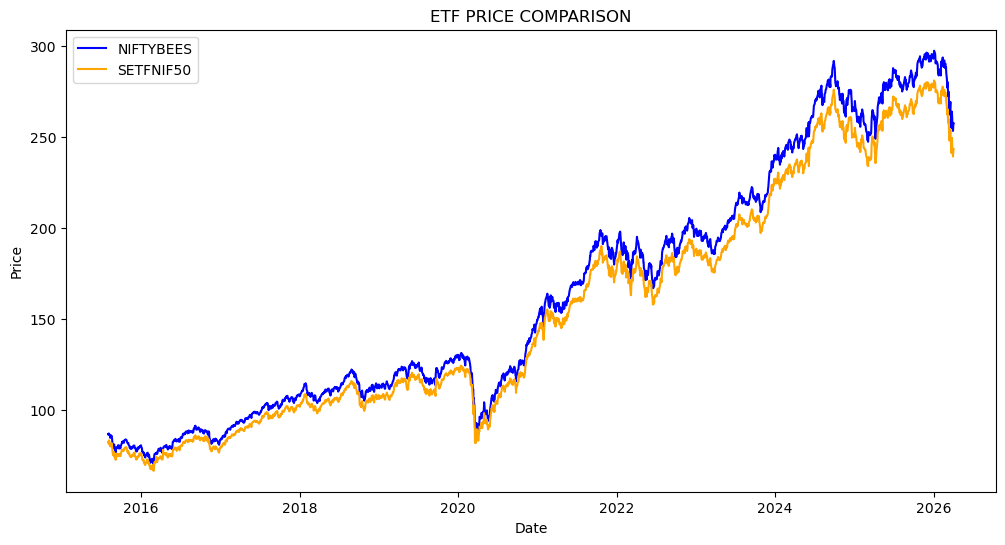

In [10]:
plt.figure(figsize=(12,6))

plt.plot(data["NIFTYBEES.NS"], label="NIFTYBEES", color="blue")
plt.plot(data["SETFNIF50.NS"], label="SETFNIF50", color="orange")

plt.title("ETF PRICE COMPARISON")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

In [11]:
# Now we can see in above image spike is completely gone.
# We will normalize this data again to check the Normalized ETF Comparison

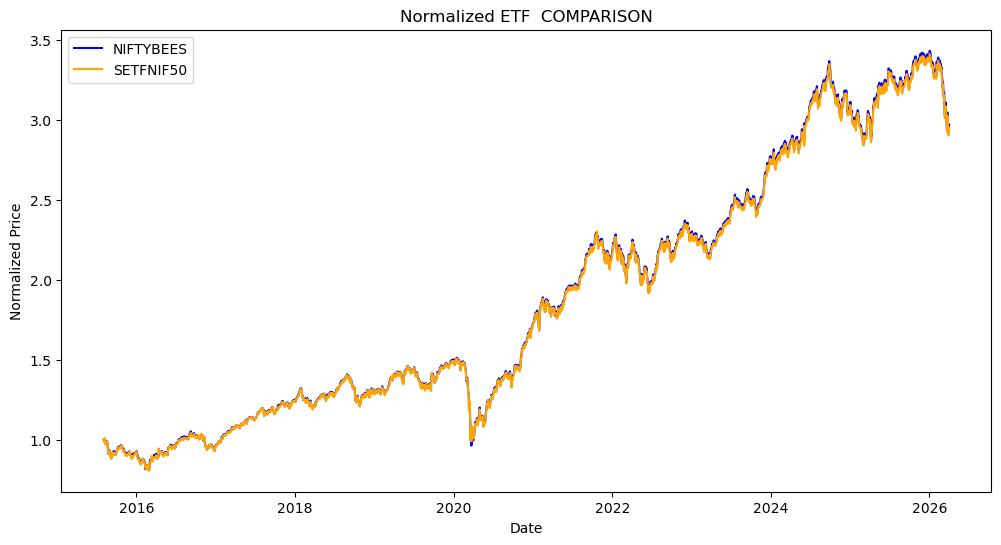

In [12]:
normalized = data/data.iloc[0]

plt.figure(figsize=(12,6))

plt.plot(normalized["NIFTYBEES.NS"], label="NIFTYBEES", color="blue")
plt.plot(normalized["SETFNIF50.NS"], label="SETFNIF50", color="orange")

plt.title("Normalized ETF  COMPARISON")
plt.xlabel("Date")
plt.ylabel("Normalized Price")

plt.legend()
plt.show()

In [13]:
data.corr()

Ticker,NIFTYBEES.NS,SETFNIF50.NS
Ticker,,
NIFTYBEES.NS,1.000000,0.999983
SETFNIF50.NS,0.999983,1.000000


In [14]:
from statsmodels.tsa.stattools import coint

score, pvalue,_= coint(data["NIFTYBEES.NS"], data["SETFNIF50.NS"])

print(pvalue)

1.3046950756235949e-17


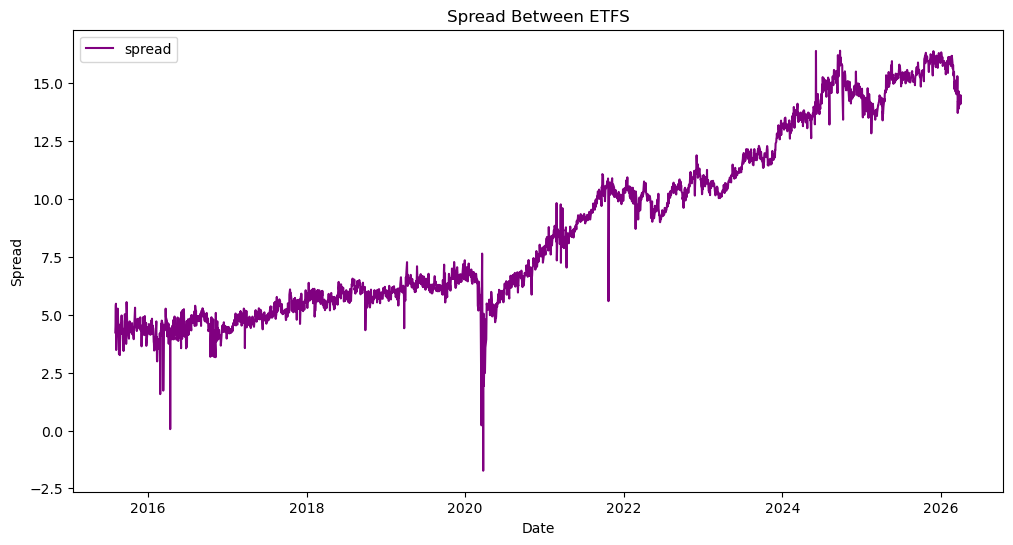

In [15]:
spread = data["NIFTYBEES.NS"] - data["SETFNIF50.NS"]

plt.figure(figsize=(12,6))

plt.plot(spread, label="spread", color="purple")

plt.title("Spread Between ETFS")
plt.xlabel("Date")
plt.ylabel("Spread")

plt.legend()
plt.show()

In [16]:
import statsmodels.api as sm

x = data["SETFNIF50.NS"]
y = data["NIFTYBEES.NS"]

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
beta = model.params[1]

print(beta)

1.059323889539114


In [17]:
spread = data["NIFTYBEES.NS"] -beta * data ["SETFNIF50.NS"]

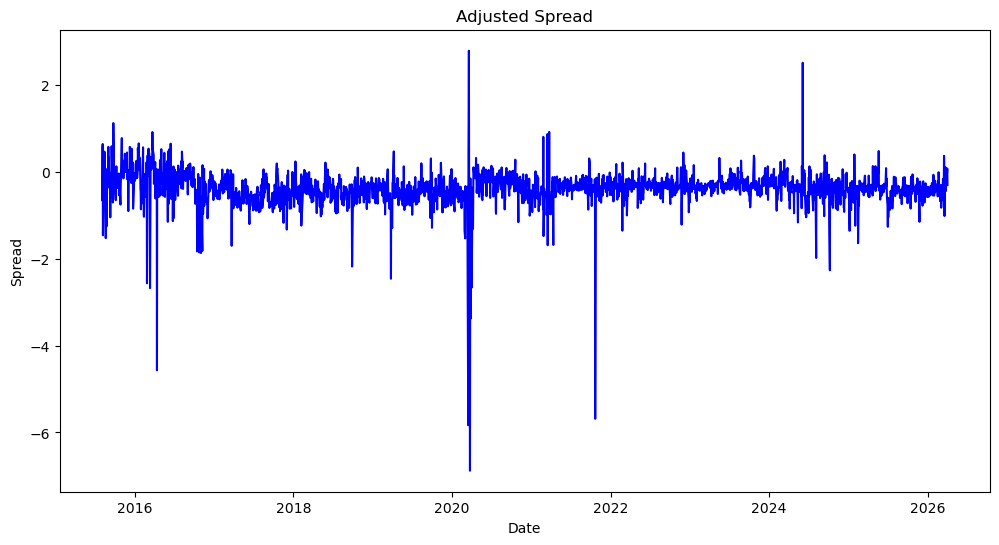

In [18]:
plt.figure(figsize=(12,6))
plt.plot(spread , label="Adjusted spread",color="blue")

plt.title("Adjusted Spread")
plt.xlabel("Date")
plt.ylabel("Spread")

plt.legend
plt.show()

In [19]:
mean = spread.mean()

std = spread.std()

zscore = (spread - mean) / std

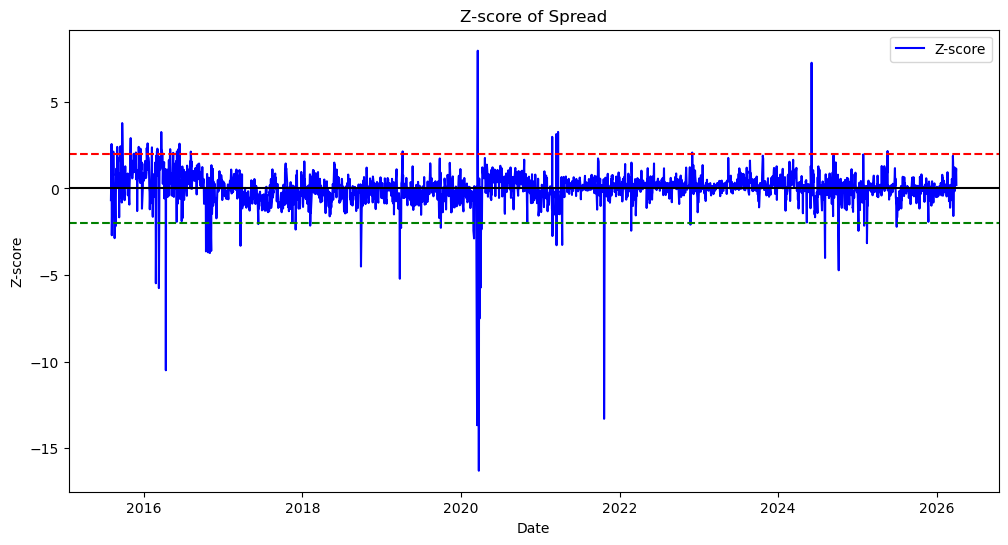

In [20]:
plt.figure(figsize=(12,6))

plt.plot(zscore, label="Z-score", color="blue")

plt.axhline(2, color="red", linestyle="--") # upper level
plt.axhline(-2, color="green", linestyle="--") # lower level
plt.axhline(0, color="black") # mean

plt.title("Z-score of Spread")
plt.xlabel("Date")
plt.ylabel("Z-score")

plt.legend()
plt.show()

In [21]:
rolling_mean = spread.rolling(window=30).mean()
rolling_std = spread.rolling(window=30).std()

zscore = (spread - rolling_mean) / rolling_std

zscore.head()

Date
2015-08-03   NaN
2015-08-04   NaN
2015-08-05   NaN
2015-08-06   NaN
2015-08-07   NaN
dtype: float64

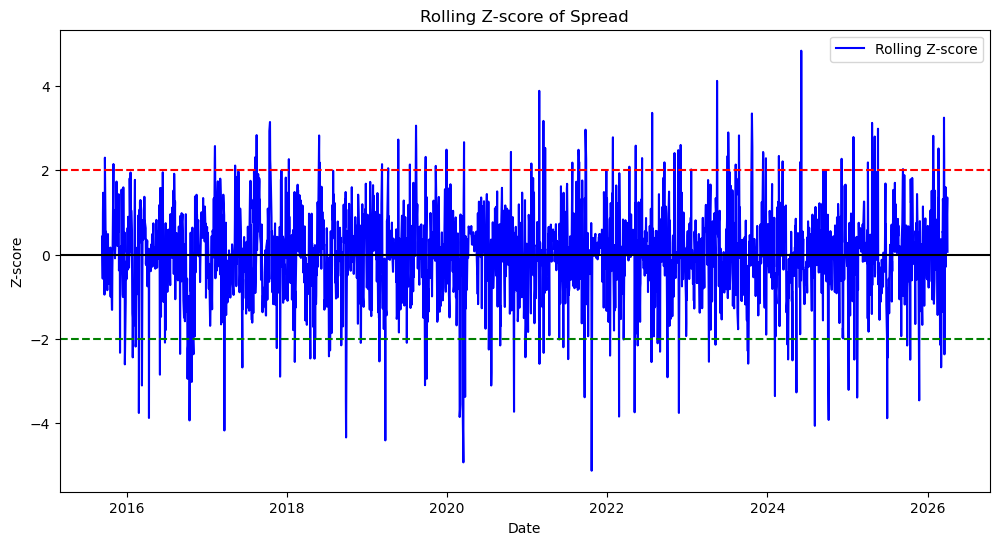

In [22]:
plt.figure(figsize=(12,6))

plt.plot(zscore, label="Rolling Z-score", color="blue")

plt.axhline(2, color="red", linestyle="--") # upper level
plt.axhline(-2, color="green", linestyle="--") # lower level
plt.axhline(0, color="black") # mean

plt.title("Rolling Z-score of Spread")
plt.xlabel("Date")
plt.ylabel("Z-score")

plt.legend()
plt.show()

In [23]:
print(zscore.max())
print(zscore.min())

4.8409459913053885
-5.1313985149624415


In [24]:
position = 0
positions = []

for i in range(len(zscore)):
    #skip nan (initial rolling window )
    if pd.isna(zscore.iloc[i]):
        positions.append(0)
        continue
    #No position > entry 
    if position == 0 :
        if zscore.iloc[i] > 2:
            position = -1 # sell spread
        elif zscore.iloc[i] < -2:
            position = 1 # Buy spread
            
    #BUY POSITION > EXIT 
    
    elif position == 1:
        if zscore.iloc[i] >= 0:
            position = 0 # exit 
            
    #SELL POSITION > EXIT 
    elif position == -1:
        if zscore.iloc[i] <= 0:
            position = 0 # exit 
            
    positions.append(position)
    
    
# save in dataframe
signals = pd.DataFrame(index=zscore.index)
signals["zscore"] = zscore 
signals["position"] = positions

In [25]:
signals["position"].value_counts()

 0    2303
 1     188
-1     139
Name: position, dtype: int64

In [26]:
signals["entry"] = 0 

signals.loc[
    (signals["position"]== 1) & (signals["position"].shift(1) == 0),
    "entry"
] = 1

signals.loc[
    (signals["position"]== -1) & (signals["position"].shift(1) == 0),
    "entry"
] = -1



In [27]:
signals["entry"].value_counts()

 0    2500
 1      70
-1      60
Name: entry, dtype: int64

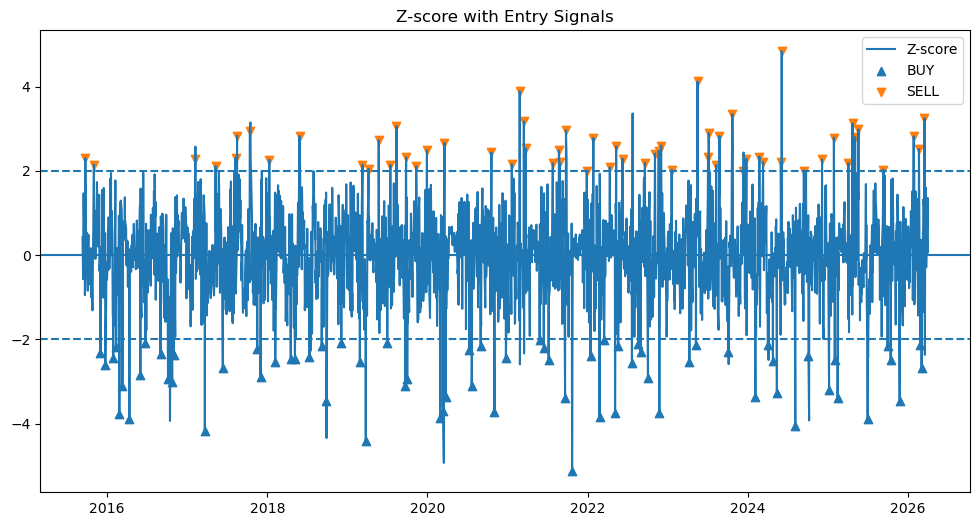

In [28]:
plt.figure(figsize=(12,6))

# Z-score line
plt.plot(signals["zscore"], label="Z-score")

# BUY entries ▲
plt.scatter(
signals.index[signals["entry"] == 1],
signals["zscore"][signals["entry"] == 1],
marker="^",
label="BUY"
)

# SELL entries ▼
plt.scatter(
signals.index[signals["entry"] == -1],
signals["zscore"][signals["entry"] == -1],
marker="v",
label="SELL"
)

# Levels
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0)

plt.title("Z-score with Entry Signals")
plt.legend()
plt.show()

In [29]:
spread_returns = spread.diff()

signals["returns"] = spread_returns
signals["strategy_returns"] = signals["position"].shift(1) * signals["returns"]

signals["cum_pnl"] = signals["strategy_returns"].cumsum()

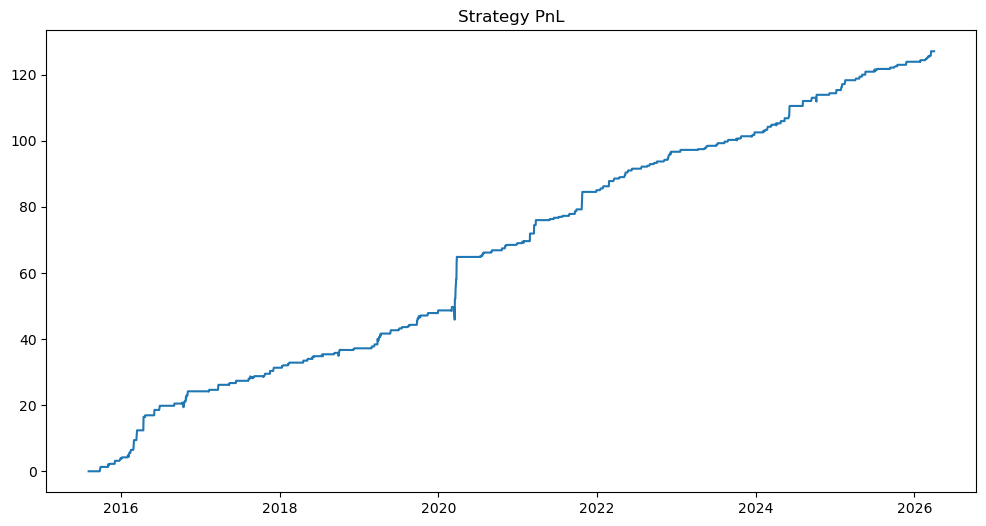

In [30]:
plt.figure(figsize=(12,6))
plt.plot(signals["cum_pnl"])
plt.title("Strategy PnL")
plt.show()


In [31]:
signals["returns_norm"] = signals["returns"] /signals["returns"].std()
signals["strategy_returns_norm"] = signals["position"].shift(1) *signals["returns_norm"]

In [32]:
sharpe = np.sqrt(252)* (
    signals["strategy_returns_norm"].mean()/signals["strategy_returns_norm"].std()
)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 2.4604328094761994


In [33]:
signals["cum_max"] = signals["cum_pnl"].cummax()
signals["drawdown"] = signals["cum_pnl"] - signals["cum_max"]

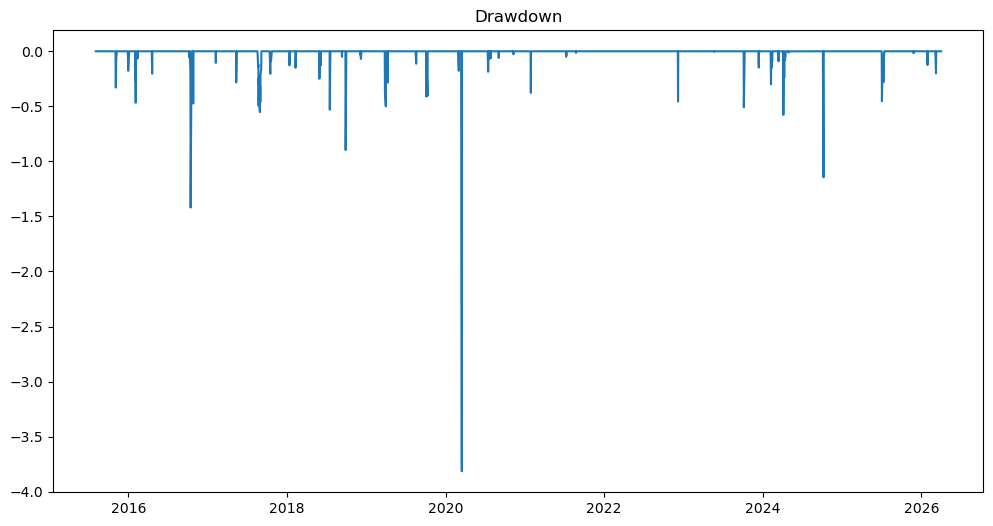

In [34]:
plt.figure(figsize=(12,6))
plt.plot(signals["drawdown"])
plt.title("Drawdown")
plt.show()

In [35]:
signals["drawdown"].min()

-3.8144891541654147

In [36]:
cost = 0.002 # 0.2% 

signals["trade_change"] = signals["position"].diff().abs()


signals["strategy_returns_cost"] = (
        signals["strategy_returns"] - cost * signals["trade_change"]
)

signals["cum_pnl_cost"] = signals["strategy_returns_cost"].cumsum()

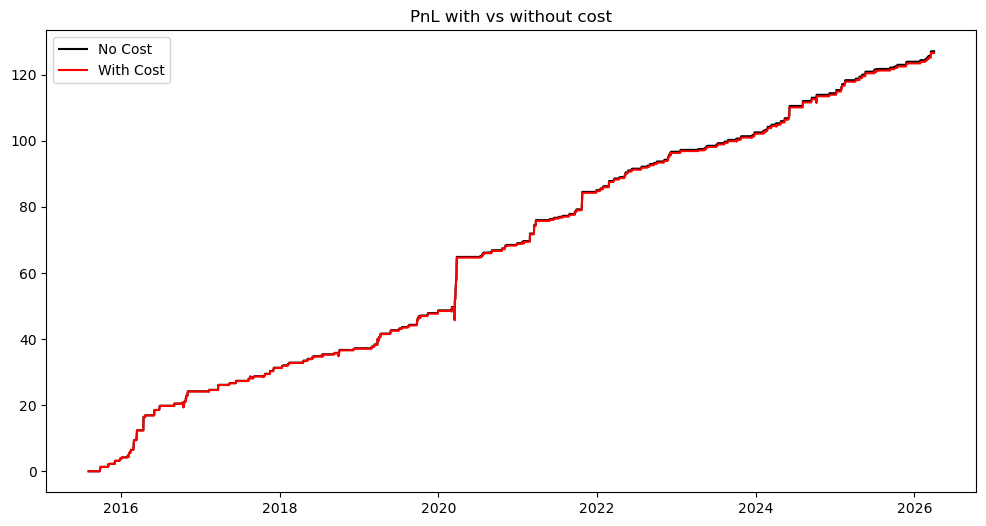

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(signals["cum_pnl"], label="No Cost", color="black")
plt.plot(signals["cum_pnl_cost"], label="With Cost", color="red")

plt.legend()
plt.title("PnL with vs without cost")
plt.show()

In [38]:
signals["trade"] = signals["entry"] != 0

total_trades = signals["trade"].sum()
print("Total Trades:", total_trades)

Total Trades: 130


In [39]:
trade_returns = signals.loc[signals["position"] != 0 , "strategy_returns"]

win_rate = (trade_returns > 0).mean()

print("Win Rate:", win_rate)

Win Rate: 0.3730886850152905


In [40]:
avg_win = trade_returns[trade_returns > 0].mean()
avg_loss = trade_returns[trade_returns < 0].mean()

print("Avg Win:", avg_win)
print("Avg Loss:", avg_loss)


Avg Win: 0.42894022200684717
Avg Loss: -0.24292666813791375


In [41]:
profit_factor = abs(
trade_returns[trade_returns > 0].sum() /
trade_returns[trade_returns < 0].sum()
)

print("Profit Factor:", profit_factor)

Profit Factor: 2.8722361627872703
